# Discrete-Time Fourier Transform (DTFT) Image Preprocessing
This notebook explores applying 2D FFT to agricultural imagery (PlantVillage). 
By shifting into the frequency domain, we apply High-Pass, Low-Pass, Band-Pass, and Band-Stop filters to see if we can isolate disease lesions or structural patterns for better CNN classification.

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from pathlib import Path

# Dynamic paths
PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.core.inference_engine import diagnose_plant_disease
except ModuleNotFoundError:
    from inference_engine import diagnose_plant_disease

# Load CNN Model
cnn_path = str(PROJECT_ROOT / "models/demeter_cnn_plantvillage.keras")
print("Loading CNN...")
cnn_model = tf.keras.models.load_model(cnn_path)

# Load class directories
plantvillage_dir = str(PROJECT_ROOT / "data/raw/vision/PlantVillage")
class_dirs = sorted([d for d in os.listdir(plantvillage_dir) if os.path.isdir(os.path.join(plantvillage_dir, d))])
print("Loaded! Classes:", len(class_dirs))

Loading CNN...
Loaded! Classes: 15


## 1. Define FFT Filter Functions

In [3]:
def get_fft(img_gray):
    """Compute 2D FFT and shift zero-frequency to center"""
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    return fshift, magnitude_spectrum

def apply_filter(fshift, filter_type, r1=30, r2=60):
    rows, cols = fshift.shape
    crow, ccol = rows // 2, cols // 2
    
    # Create mask
    mask = np.zeros((rows, cols), np.uint8)
    
    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
    
    if filter_type == "lowpass":
        mask[dist_from_center <= r1] = 1
    elif filter_type == "highpass":
        mask[dist_from_center > r1] = 1
    elif filter_type == "bandpass":
        mask[(dist_from_center >= r1) & (dist_from_center <= r2)] = 1
    elif filter_type == "bandstop":
        mask[dist_from_center < r1] = 1
        mask[dist_from_center > r2] = 1
        
    return fshift * mask, mask

def get_ifft(fshift_filtered):
    """Inverse FFT to get spatial image back"""
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    # Normalize to 0-255
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return img_back

## 2. Load Sample Images (Diseased & Healthy)

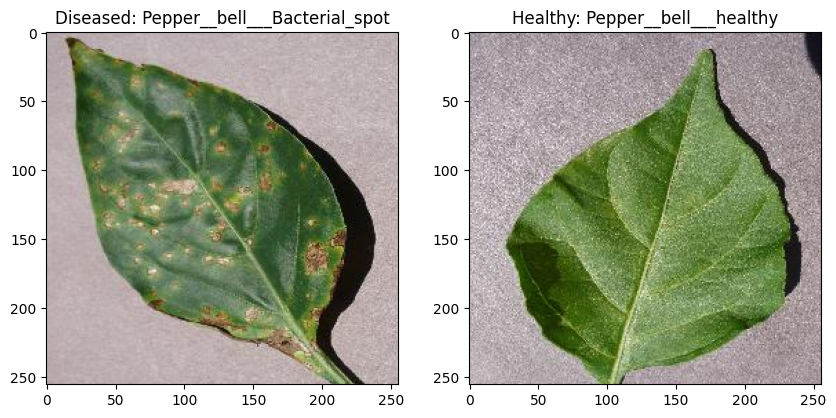

In [4]:
import random

# Find a diseased class and a healthy class
disease_class = next(c for c in class_dirs if "healthy" not in c.lower())
healthy_class = next(c for c in class_dirs if "healthy" in c.lower())

def get_random_image(class_name):
    path = os.path.join(plantvillage_dir, class_name)
    imgs = [f for f in os.listdir(path) if f.endswith((".jpg", ".JPG"))]
    return os.path.join(path, random.choice(imgs))

img_disease_path = get_random_image(disease_class)
img_healthy_path = get_random_image(healthy_class)

# Load grayscale for FFT and RGB for visualization
img_disease_rgb = cv2.cvtColor(cv2.imread(img_disease_path), cv2.COLOR_BGR2RGB)
img_disease_gray = cv2.cvtColor(img_disease_rgb, cv2.COLOR_RGB2GRAY)

img_healthy_rgb = cv2.cvtColor(cv2.imread(img_healthy_path), cv2.COLOR_BGR2RGB)
img_healthy_gray = cv2.cvtColor(img_healthy_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img_disease_rgb), plt.title(f"Diseased: {disease_class}")
plt.subplot(1, 2, 2), plt.imshow(img_healthy_rgb), plt.title(f"Healthy: {healthy_class}")
plt.show()

## 3. Visualize Magnitude Spectrums

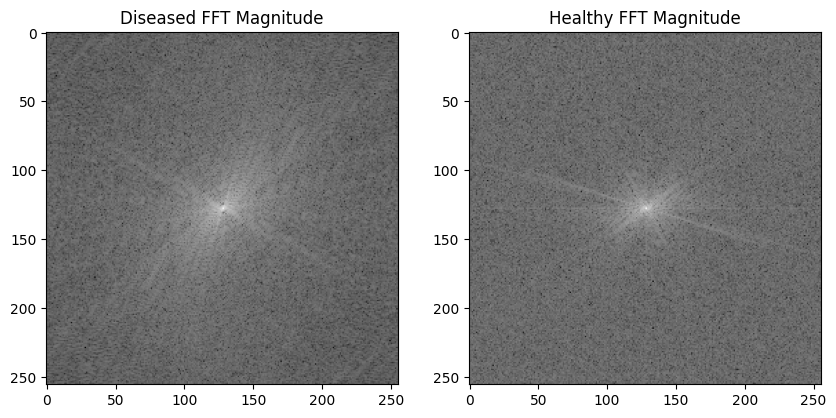

In [5]:
fshift_d, mag_d = get_fft(img_disease_gray)
fshift_h, mag_h = get_fft(img_healthy_gray)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(mag_d, cmap="gray"), plt.title("Diseased FFT Magnitude")
plt.subplot(1, 2, 2), plt.imshow(mag_h, cmap="gray"), plt.title("Healthy FFT Magnitude")
plt.show()

## 4. Apply Filters & Inverse FFT (Reconstruction)
Let us see how different filters affect the diseased image.

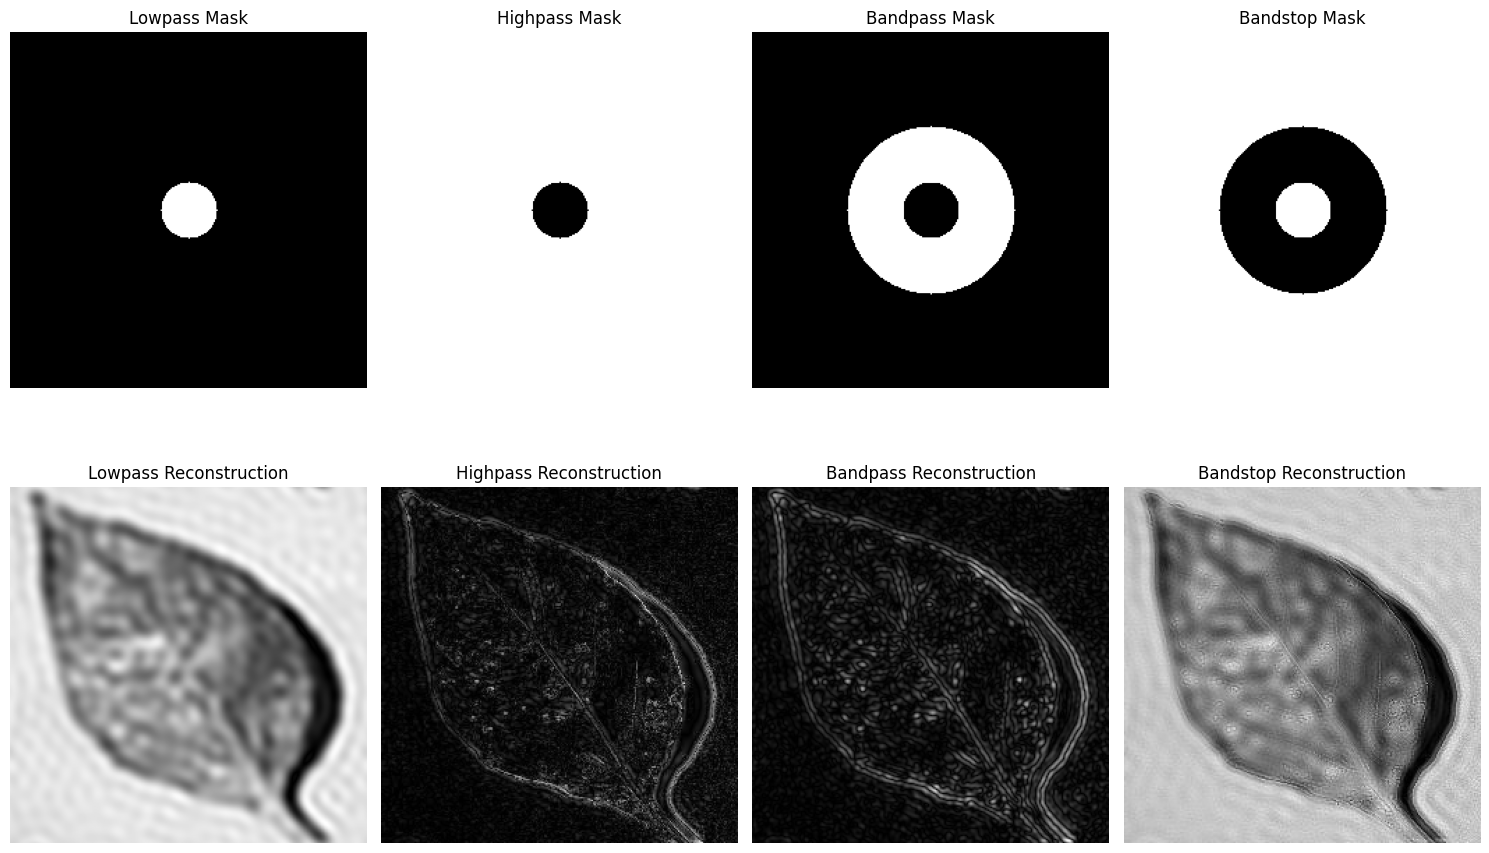

In [6]:
filters = ["lowpass", "highpass", "bandpass", "bandstop"]
r1, r2 = 20, 60

plt.figure(figsize=(15, 10))
for i, f_type in enumerate(filters):
    fshift_filtered, mask = apply_filter(fshift_d, f_type, r1, r2)
    img_reconstructed = get_ifft(fshift_filtered)
    
    plt.subplot(2, 4, i+1)
    plt.imshow(mask, cmap="gray")
    plt.title(f"{f_type.capitalize()} Mask")
    plt.axis("off")
    
    plt.subplot(2, 4, i+5)
    plt.imshow(img_reconstructed, cmap="gray")
    plt.title(f"{f_type.capitalize()} Reconstruction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Evaluate CNN Performance on Preprocessed Images
We will take the reconstructed 1-channel images, convert them back to 3-channel (RGB), and pass them to the CNN to see if confidence increases.

In [7]:
def predict_on_img(img_array, title):
    # Resize to 150x150 as expected by CNN
    img_resized = cv2.resize(img_array, (150, 150))
    
    # If grayscale, convert to 3 channel
    if len(img_resized.shape) == 2:
        img_resized = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)
        
    img_tensor = tf.expand_dims(img_resized, 0)
    
    # Use inference engine
    res = diagnose_plant_disease(img_tensor, "memory", cnn_model, class_dirs)
    print(f"{title:<20} -> {res[\"Detected_Disease\"]:<25} (Conf: {res[\"Disease_Confidence\"]:.2%})")

print("--- DISEASED LEAF EVALUATION ---" )
predict_on_img(img_disease_rgb, "Raw RGB")
predict_on_img(img_disease_gray, "Raw Grayscale")
for f_type in filters:
    fshift_filtered, _ = apply_filter(fshift_d, f_type, 20, 60)
    img_reconstructed = get_ifft(fshift_filtered)
    predict_on_img(img_reconstructed, f_type.capitalize())

print("\n--- HEALTHY LEAF EVALUATION ---" )
predict_on_img(img_healthy_rgb, "Raw RGB")
predict_on_img(img_healthy_gray, "Raw Grayscale")
for f_type in filters:
    fshift_filtered, _ = apply_filter(fshift_h, f_type, 20, 60)
    img_reconstructed = get_ifft(fshift_filtered)
    predict_on_img(img_reconstructed, f_type.capitalize())

SyntaxError: f-string expression part cannot include a backslash (2010851724.py, line 13)